## Quadratic Functions

Batch Gradient Descent can also be used to model data that doesn't fit a linear function. Here, we will fit data to a quadratic as an example.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

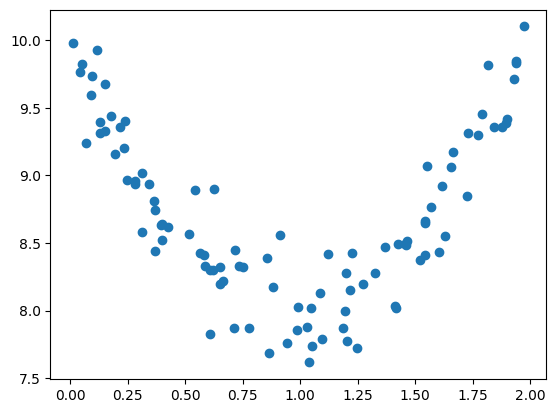

In [2]:
np.random.seed(42) #keep the same random data every time we run the code

m = 100 #training examples
n = 2 #features
x = np.array(2 * np.random.rand(m, 1)) #random input values
x = np.sort(x, axis = 0) #sort x inputs (to make better plot later)

X = np.hstack((np.ones((m, 1)), x, x ** 2))

y = np.array(2 * (x ** 2) - 4 * x + 10 + 0.25 * np.random.randn(m,1))
# a = 2, b = -4, c = 10 + noise

plt.scatter(X[:, 1], y)
plt.show()

In [3]:
def predict(X, theta):
    # h(theta)
    return X @ theta 


def cost_function(X, y, theta):
    # J(theta)
    m = len(y)
    errors = predict(X, theta) - y
    return 0.5 * np.sum(errors ** 2) / m

def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []

    for _ in range(iterations):
        cost_history.append(cost_function(X, y, theta))
        errors = predict(X, theta) - y
        theta = theta - (alpha / m) * X.T @ errors
        
    return theta, cost_history

Learning rate 0.2, function: f(x) = [1.87544522]x^2 + [-3.70923202]x + [9.87867049]
Learning rate 0.25, function: f(x) = [1.94334635]x^2 + [-3.84992163]x + [9.92791359]
Learning rate 0.3, function: f(x) = [1.97389845]x^2 + [-3.91322489]x + [9.95007052]
Learning rate 0.35, function: f(x) = [1.98763658]x^2 + [-3.94168999]x + [9.96003365]
Learning rate 0.38, function: f(x) = [1.99191058]x^2 + [-3.95054562]x + [9.96313323]
Learning rate 0.4, function: f(x) = [1.99381015]x^2 + [-3.95448149]x + [9.96451084]


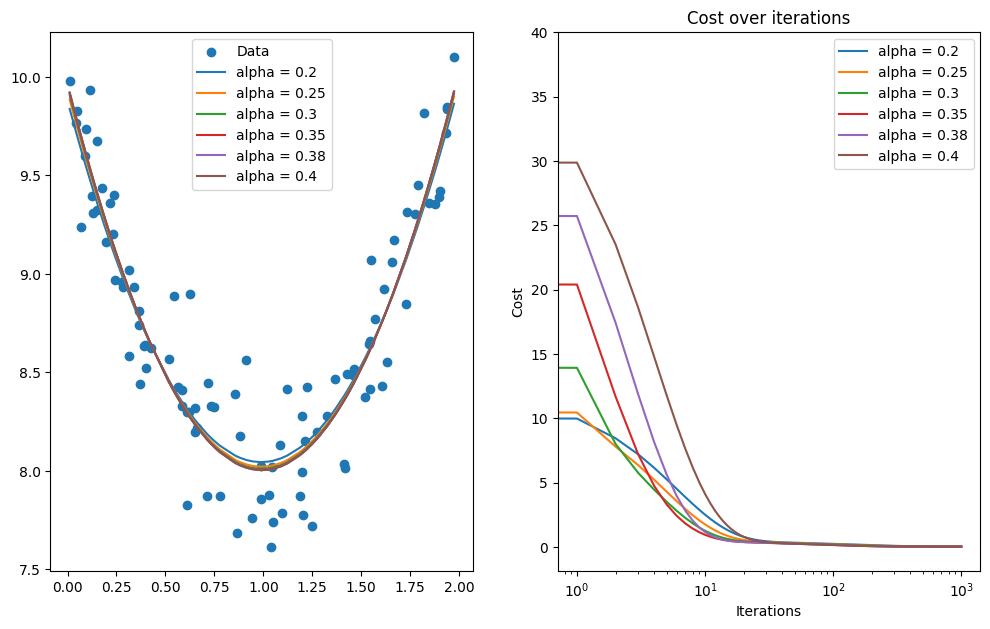

In [124]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7))

theta0 = np.zeros((n+1, 1)) #initial parameter value
learning_rates = np.array([0.2, 0.25, 0.3, 0.35, 0.38, 0.4])
iterations = 1000

ax1.scatter(X[:, 1], y, label = 'Data')

for rate in learning_rates:
    theta, cost_history = gradient_descent(X, y, theta0, rate, iterations)
    print(f'Learning rate {rate}, function: f(x) = {theta[2]}x^2 + {theta[1]}x + {theta[0]}')
    y_pred = predict(X, theta)
    ax1.plot(X[:,1], y_pred, label = f'alpha = {rate}')
    ax2.plot(cost_history, label = f'alpha = {rate}')

ax1.legend()
ax2.legend()
ax2.set_xscale('log')
ax2.set_title('Cost over iterations')
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Cost')
plt.show() 

## Trigonometric Functions

Let us now do the same for more complex functions as to evaluate the performance of Batch Gradient Descent on such complicated scenarios.

Consider now a dataset that is modeled by trig functions. Similarly to the quadratic function, we can apply Gradient Descent by adding some features to $x$. In this case, we'll add $\sin(x)$ and $\cos(x)$, and keep $x$ as well.

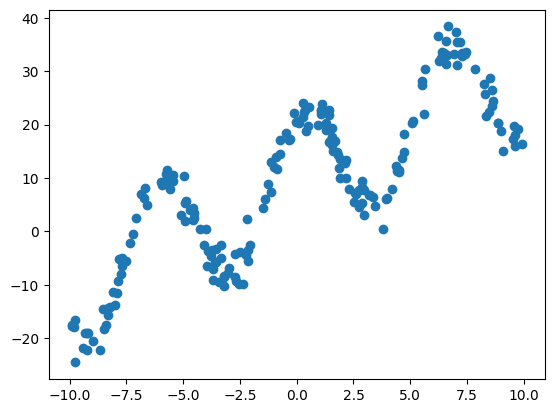

In [83]:
m_sinusoidal = 200
n_sinusoidal = 3

x_sinusoidal = np.array(20 * np.random.rand(m_sinusoidal, 1)) - 10 #random input values
x_sinusoidal = np.sort(x_sinusoidal, axis = 0) #sort x inputs (to make better plot later)

X_sinusoidal = np.hstack((np.ones((m_sinusoidal, 1)), x_sinusoidal, np.sin(x_sinusoidal), np.cos(x_sinusoidal)))

y_sinusoidal = np.array(2 * x_sinusoidal + 12 * np.sin(x_sinusoidal - 5) + 10 + 2 * np.random.randn(m_sinusoidal,1))
# y = 2x + 12sin(x - 5) + 10 + noise

plt.scatter(X_sinusoidal[:, 1], y_sinusoidal)
plt.show()

Learning rate 0.01, function: f(x) = [10.08194679] + [2.00357739]x + [3.68077646] sin(x) + [11.38970424]cos(x)
Learning rate 0.03, function: f(x) = [10.08327201] + [2.00201026]x + [3.73910169] sin(x) + [11.44366728]cos(x)
Learning rate 0.05, function: f(x) = [10.08327225] + [2.00201]x + [3.73911127] sin(x) + [11.44366899]cos(x)
Learning rate 0.06, function: f(x) = [10.08327225] + [2.00201]x + [3.73911127] sin(x) + [11.44366899]cos(x)


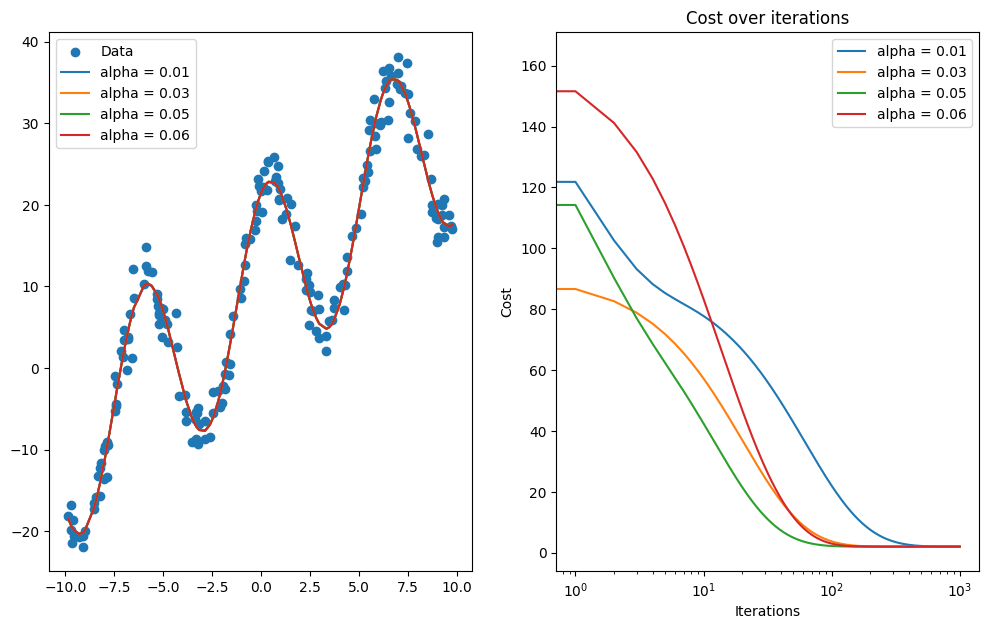

In [60]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7))

theta0_sinusoidal = np.zeros((n_sinusoidal+1, 1)) #initial parameter value
learning_rates_sinusoidal = np.array([0.01, 0.03, 0.05, 0.06])
iterations_sinusoidal = 1000

ax1.scatter(X_sinusoidal[:, 1], y_sinusoidal, label = 'Data')

for rate in learning_rates_sinusoidal:
    theta, cost_history = gradient_descent(X_sinusoidal, y_sinusoidal, theta0_sinusoidal, rate, iterations_sinusoidal)
    print(f'Learning rate {rate}, function: f(x) = {theta[0]} + {theta[1]}x + {theta[2]} sin(x) + {theta[3]}cos(x)')
    y_pred_sinusoidal = predict(X_sinusoidal, theta)
    ax1.plot(X_sinusoidal[:,1], y_pred_sinusoidal, label = f'alpha = {rate}')
    ax2.plot(cost_history, label = f'alpha = {rate}')

ax1.legend()
ax2.legend()
ax2.set_xscale('log')
ax2.set_title('Cost over iterations')
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Cost')
plt.show() 

## Exponentials

Let us now apply the same learning algorithm to data modeled by an exponential function.

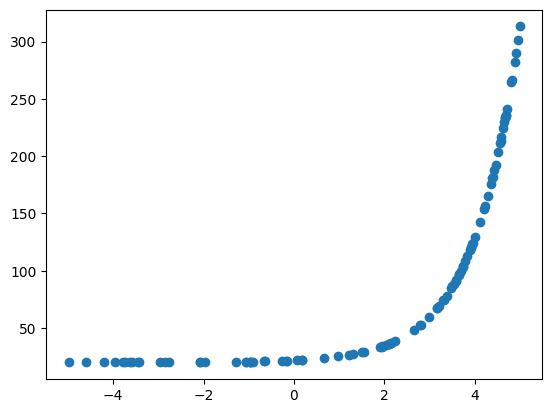

In [101]:
m_exponential = 100
n_exponential = 2

# Create different arrays for different parts of the sampling space
arr1 = 8 * np.random.rand(50) - 5
arr2 = 2 * np.random.rand(m_exponential - 50) + 3

# Crate input array
x_exponential = np.reshape(np.concatenate((arr1, arr2)), (m_exponential, 1)) 
x_exponential = np.sort(x_exponential, axis = 0) #sort x inputs (to make better plot later)

X_exponential = np.hstack((np.ones((m_exponential, 1)), x_exponential, np.e ** x_exponential))

y_exponential = np.array(2 * np.e ** x_exponential + 20)
# y = 2e^x + 20 + noise

plt.scatter(X_exponential[:, 1], y_exponential)
plt.show()

Learning rate 0.0001, function: f(x) = [8.63161206] + [-0.22639487]x + [2.14519365]e^x
Learning rate 0.0003, function: f(x) = [16.31353281] + [-0.07890409]x + [2.04735932]e^x
Learning rate 0.0005, function: f(x) = [18.80468879] + [-0.02558951]x + [2.0153562]e^x
Learning rate 0.0006, function: f(x) = [19.31939417] + [-0.01457058]x + [2.00874377]e^x


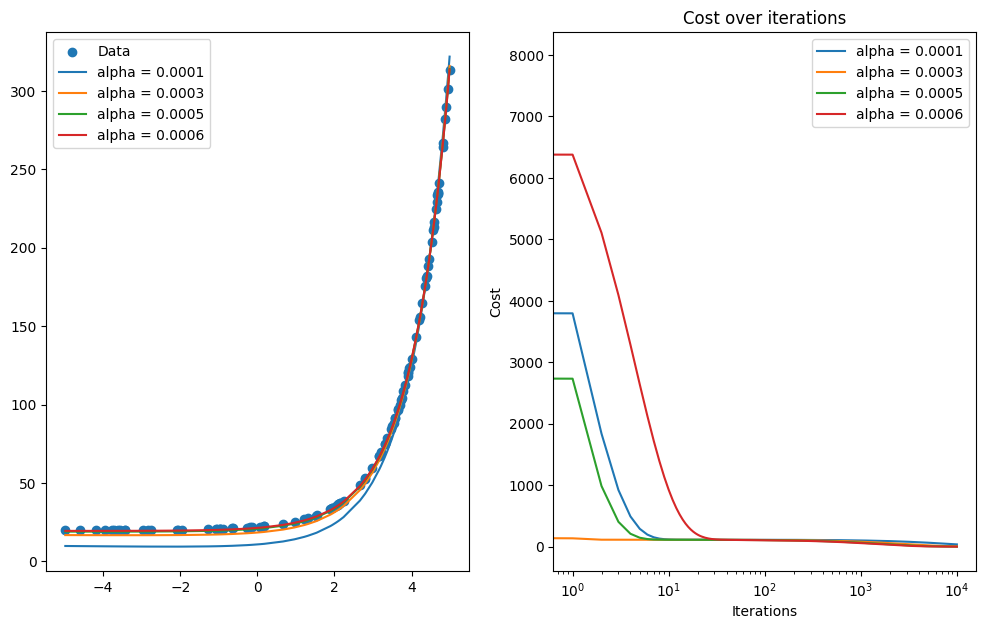

In [126]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7))

theta0_exponential = np.zeros((n_exponential+1, 1)) #initial parameter value
learning_rates_exponential = np.array([1e-4, 3e-4, 5e-4, 6e-4])
iterations_exponential = 10000

ax1.scatter(X_exponential[:, 1], y_exponential, label = 'Data')

for rate in learning_rates_exponential:
    theta, cost_history = gradient_descent(X_exponential, y_exponential, theta0_exponential, rate, iterations_exponential)
    print(f'Learning rate {rate}, function: f(x) = {theta[0]} + {theta[1]}x + {theta[2]}e^x')
    y_pred_exponential = predict(X_exponential, theta)
    ax1.plot(X_exponential[:,1], y_pred_exponential, label = f'alpha = {rate}')
    ax2.plot(cost_history, label = f'alpha = {rate}')

ax1.legend()
ax2.legend()
ax2.set_xscale('log')
ax2.set_title('Cost over iterations')
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Cost')
plt.show() 

This last dataset shows how Batch GD becomes expensive in some cases. Here, we needed 10 thousand iterations to get to a proper model, with a optimal learning rate of about 6e-4, which is extremely low. Such low learning rate is due to the fact that exponentials change rapidly, so that slight changes in the algorithm create very different outputs.